# Entanglement: the four Bell states versus unentangled states

The four Bell states are the simplest maximally entangled two-qubit states:

$$|\Phi^\pm\rangle = \tfrac{1}{\sqrt2}(|00\rangle \pm |11\rangle)
\qquad
|\Psi^\pm\rangle = \tfrac{1}{\sqrt2}(|01\rangle \pm |10\rangle)$$

One circuit makes all four. Start with qubit 0 in state $a$ and qubit 1 in state $b$, written $(a, b)$ with qubit 0 first. Apply X gates to set $a$ and $b$, then H on qubit 0 and CX (control 0, target 1).

| input $(a, b)$ | output |
|---|---|
| (0, 0) | $\Phi^+$ |
| (1, 0) | $\Phi^-$ |
| (0, 1) | $\Psi^+$ |
| (1, 1) | $\Psi^-$ (up to a global phase) |

Careful: Qiskit prints bitstrings with qubit 0 on the *right*, so the input $(a, b) = (1, 0)$ is the label `01` in Qiskit's counts. State labels below follow the same order: in $|0{+}\rangle$, qubit 1 is $|0\rangle$ and qubit 0 is $|{+}\rangle$.\n\nFor comparison we also build three *unentangled* (product) states: $|00\rangle$, $|{+}{+}\rangle$, and $|0{+}\rangle$.

## Telling them apart takes more than one basis

- **Z basis.** $\Phi^+$ and $\Phi^-$ give the *same* counts (only 00 and 11). The sign between the terms is a phase, invisible to a Z measurement.
- **X basis.** To measure in the X basis, do a *change of basis*: apply H to each qubit, then measure in Z (because $X = HZH$). Now $\Phi^+$ and $\Phi^-$ differ.

## Correlators with an Estimator

An Estimator returns expectation values of observables directly:

| state | ZZ | XX | YY |
|---|---|---|---|
| $\Phi^+$ | +1 | +1 | -1 |
| $\Phi^-$ | +1 | -1 | +1 |
| $\Psi^+$ | -1 | +1 | +1 |
| $\Psi^-$ | -1 | -1 | -1 |
| $\lvert{+}{+}\rangle$ | 0 | +1 | 0 |

**Entanglement witness:** $S = |\langle ZZ\rangle| + |\langle XX\rangle| + |\langle YY\rangle|$. For any product state $S \le 1$ (by the Cauchy-Schwarz inequality; by convexity this also holds for any mixture of product states, so noisy hardware cannot fake it). Bell states have $S = 3$. Seeing $S > 1$ proves the qubits are entangled.

## The steps

Every example in this folder follows the same recipe:

1. **Circuit**: build the abstract circuit.
2. **Transpile**: rewrite it into the gates and qubits the backend supports (an "ISA circuit").
3. **Observable**: what to measure (Estimator only).
4. **PUB**: bundle what to run (a Primitive Unified Bloc, a tuple that starts with the circuit).
5. **Execute**: hand the PUBs to a primitive and wait for the job.
6. **Read**: turn the raw result into numbers and compare with theory.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# _runtime.py (in ../scripts) only decides *where* to run: Aer and/or IBM hardware.
# Run this notebook from its own folder (the default in Jupyter and VS Code).
# The next line looks for the helper file one folder up, in ../scripts.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from _runtime import get_targets

np.set_printoptions(precision=3, suppress=True)

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit (Sampler jobs)
    precision=0.02,              # target standard error (Estimator jobs)
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)
targets = get_targets(SETTINGS)
print("Running on:", [t.label for t in targets])

Running on: ['aer']


## Step 1: Circuits

`build_state` makes each state without measurements. `measured` adds either a plain Z measurement or the H change of basis first.

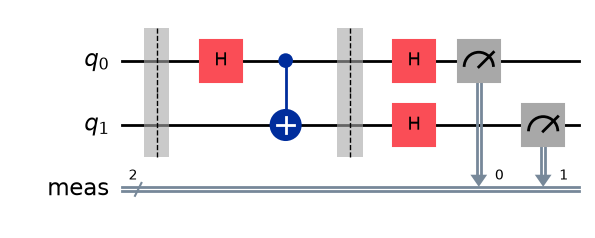

In [2]:
BELL_BITS = {"Phi+": (0, 0), "Phi-": (1, 0), "Psi+": (0, 1), "Psi-": (1, 1)}


def build_state(name):
    qubits = QuantumRegister(2, name="q")
    circuit = QuantumCircuit(qubits, name=name)
    if name in BELL_BITS:
        a, b = BELL_BITS[name]
        if a:
            circuit.x(qubits[0])
        if b:
            circuit.x(qubits[1])
        circuit.barrier()
        circuit.h(qubits[0])               # superposition on qubit 0 ...
        circuit.cx(qubits[0], qubits[1])   # ... shared with qubit 1: entanglement
    elif name == "|++>":
        circuit.h(qubits[0])
        circuit.h(qubits[1])
    elif name == "|0+>":
        circuit.h(qubits[0])
    elif name != "|00>":
        raise ValueError(f"Unknown state {name!r}")
    return circuit


def measured(state, basis):
    circuit = state.copy(name=f"{state.name}_{basis}")
    bits = ClassicalRegister(2, name="meas")
    circuit.add_register(bits)
    circuit.barrier()
    if basis == "X":
        circuit.h([0, 1])                  # change of basis
    circuit.measure(circuit.qubits, bits)
    return circuit


names = list(BELL_BITS) + ["|00>", "|++>", "|0+>"]
states = {n: build_state(n) for n in names}
measured(states["Phi+"], "X").draw("mpl")

## Step 3: Observable (defined early)

The observables do not depend on the backend, so we define them now. Each Pauli string has the same letter on both qubits, so the order of the letters does not matter here.

In [3]:
from qiskit.quantum_info import SparsePauliOp, Statevector

observables = [SparsePauliOp(p) for p in ("ZZ", "XX", "YY")]
print(observables)

[SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['XX'],
              coeffs=[1.+0.j]), SparsePauliOp(['YY'],
              coeffs=[1.+0.j])]


## Part A: Sampler (counts in the Z and X bases)

### Steps 2, 4, 5: transpile, build PUBs, execute

In [4]:
sampler_results = {}
for target in targets:
    # Step 2: transpile
    pass_manager = generate_preset_pass_manager(backend=target.backend, optimization_level=1)
    sampler_circuits = [
        pass_manager.run(measured(c, basis)) for c in states.values() for basis in ("Z", "X")
    ]
    # Step 4: one PUB per circuit
    sampler_pubs = [(isa,) for isa in sampler_circuits]
    # Step 5: one job carries all of them
    print(f"{target.label}: {len(sampler_pubs)} PUBs in one job")
    sampler_results[target.label] = target.wait(
        target.sampler.run(sampler_pubs, shots=SETTINGS.shots)
    )

aer: 14 PUBs in one job


### Step 6: Read the counts

Bitstrings read `q1 q0` (qubit 0 on the right).

In [5]:
for label, result in sampler_results.items():
    if result is None:
        continue
    print(f"Sampler counts ({SETTINGS.shots} shots) on {label}")
    for i, name in enumerate(states):
        z = result[2 * i].data.meas.get_counts()
        x = result[2 * i + 1].data.meas.get_counts()
        print(f"  {name:5s} Z: {dict(sorted(z.items()))}")
        print(f"  {'':5s} X: {dict(sorted(x.items()))}")

Sampler counts (4096 shots) on aer
  Phi+  Z: {'00': 2075, '11': 2021}
        X: {'00': 2063, '11': 2033}
  Phi-  Z: {'00': 2072, '11': 2024}
        X: {'01': 2068, '10': 2028}
  Psi+  Z: {'01': 2064, '10': 2032}
        X: {'00': 2048, '11': 2048}
  Psi-  Z: {'01': 2074, '10': 2022}
        X: {'01': 2058, '10': 2038}
  |00>  Z: {'00': 4096}
        X: {'00': 1064, '01': 1058, '10': 1003, '11': 971}
  |++>  Z: {'00': 964, '01': 1089, '10': 1024, '11': 1019}
        X: {'00': 4096}
  |0+>  Z: {'00': 2018, '01': 2078}
        X: {'00': 2086, '10': 2010}


## Part B: Estimator (correlators)

### Steps 2 to 5

Here we transpile the circuits *without* measurements, since the Estimator adds whatever basis changes it needs. The transpiler may move our qubits to other physical qubits, so `apply_layout` rewrites each observable to act on the same ones. The PUB is `(circuit, observables)`; a list of three observables gives three expectation values from one PUB.

In [6]:
estimator_results = {}
for target in targets:
    if sampler_results[target.label] is None:
        continue  # the Sampler job failed; do not submit another
    pass_manager = generate_preset_pass_manager(backend=target.backend, optimization_level=1)
    estimator_pubs = []
    for circuit in states.values():
        isa = pass_manager.run(circuit)
        isa_observables = [obs.apply_layout(isa.layout) for obs in observables]
        estimator_pubs.append((isa, isa_observables))
    print(f"{target.label}: {len(estimator_pubs)} PUBs in one job")
    estimator_results[target.label] = target.wait(
        target.estimator.run(estimator_pubs, precision=SETTINGS.precision)
    )

aer: 7 PUBs in one job


### Step 6: Read the results

`evs` are the expectation values and `stds` their standard errors. On IBM hardware the values come from finite shots, and by default IBM's Estimator also applies some error mitigation (typically readout-error mitigation) that the Sampler does not, so the correlators can look cleaner than the raw counts for that reason. Aer has no shots: its Estimator returns the exact value plus random noise of size `precision`, so a value can land slightly outside $[-1, 1]$. Either way, noise can push a product state slightly above $S = 1$, so we only claim entanglement when $S$ clears 1 by three standard errors.

In [7]:
for label, result in estimator_results.items():
    if result is None:
        continue
    print(f"Estimator on {label} (precision {SETTINGS.precision})")
    print(f"  {'state':5s}   <ZZ>    <XX>    <YY>      S    ideal S")
    for (name, circuit), pub_result in zip(states.items(), result):
        ev = np.asarray(pub_result.data.evs)
        ideal = Statevector(circuit)
        ideal_s = sum(abs(ideal.expectation_value(o).real) for o in observables)
        s = np.abs(ev).sum()
        s_err = np.sqrt(np.sum(np.asarray(pub_result.data.stds) ** 2))
        verdict = "entangled" if s > 1 + 3 * s_err else "no entanglement shown"
        print(f"  {name:5s} {ev[0]:+7.3f} {ev[1]:+7.3f} {ev[2]:+7.3f}"
              f" {s:6.2f}    {ideal_s:4.1f}   {verdict}")

Estimator on aer (precision 0.02)
  state   <ZZ>    <XX>    <YY>      S    ideal S
  Phi+   +0.990  +0.978  -1.007   2.97     3.0   entangled
  Phi-   +1.001  -1.003  +0.994   3.00     3.0   entangled
  Psi+   -0.969  +1.010  +0.990   2.97     3.0   entangled
  Psi-   -1.002  -0.969  -0.987   2.96     3.0   entangled
  |00>   +1.020  +0.023  +0.018   1.06     1.0   no entanglement shown
  |++>   +0.007  +0.981  +0.033   1.02     1.0   no entanglement shown
  |0+>   -0.043  -0.012  -0.013   0.07     0.0   no entanglement shown


## Takeaway

$\Phi^+$ and $\Phi^-$ look identical in the Z basis but differ in the X basis. An $S$ clearly above 1 certifies entanglement, because product states can never exceed 1.